<a href="https://colab.research.google.com/github/ayush4628/Quora-Duplicate-Question-Pairs/blob/main/Initial_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/questions.csv")

In [6]:
df.shape

(404351, 6)

In [7]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
317557,317557,623110,623111,How do I stop a German Shepherd/Border Collie ...,How do I stop my Pit Bull/English Bulldog mix ...,1
290423,290423,570626,570627,What is your review of Strings (2004 movie)?,What is your review of Some (2004 movie)?,0
366334,366334,717036,717037,What is the best material for Hadoop?,What are the best sources for learning Hadoop?,1
342092,342092,670521,670522,"Who would win in a fight, Bruce Lee or Muhamma...",Who would win a fight Bruce Lee or Muhammad Ali?,1
341154,341154,668719,668720,What are the different versions of Visual Stud...,What are different versions of Visual studio?,1
131103,131103,259669,259670,How do I hide apps on an Android phone without...,How can I hide images and videos on my Android...,0
323360,323360,634324,634325,How can I log out from instagram on other devi...,How do you log out of Instagram?,0
159163,159163,314718,314719,Are people answering on Quora lonely and/ or u...,Is Quora full of lonely and unemployed people?,1
31021,31021,61838,61839,How many episodes of Fairy Tail are English-du...,Where do I find English-dubbed episodes of Fai...,0
73465,73465,145987,145988,What are the best things to do in Goa with my ...,Should one go to Goa in May for vacation?,0


In [8]:
df.tail()

,id,qid1,qid2,question1,question2,is_duplicate
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404348,404348,789796,789797,What is one coin?,What's this coin?,0
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0
404350,404350,789800,789801,What is like to have sex with cousin?,What is it like to have sex with your cousin?,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [10]:
# Missing values
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [11]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255045
1    149306
Name: count, dtype: int64
is_duplicate
0    63.07515
1    36.92485
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

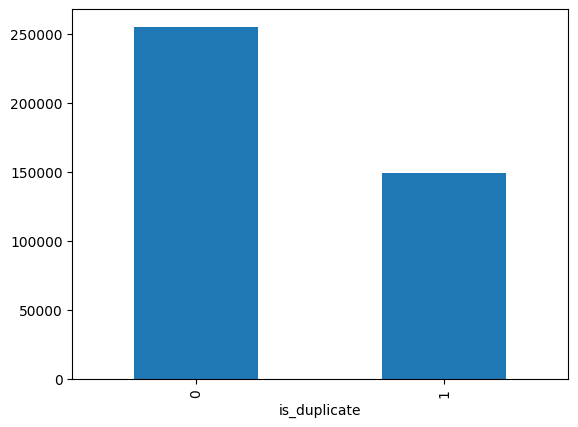

In [12]:
# Distribution of duplicate and non-duplicate questions

print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [13]:
# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print("Number of unique questions", np.unique(qid).shape[0])
x = qid.value_counts()>1
print("Number of questions getting repeated", x[x].shape[0])

Number of unique questions 789801
Number of questions getting repeated 13698


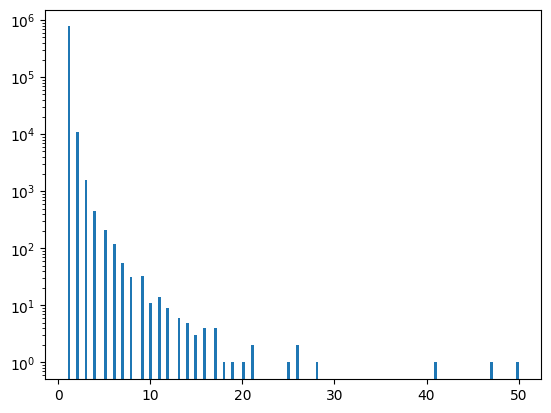

In [14]:
# Repeated questions histogram

plt.hist(qid.value_counts().values, bins=160)
plt.yscale('log')
plt.show()